# Exercises XP: Introduction to Deep Learning

Week 9, Day 4

**What you will learn**
- The fundamentals of deep learning and neural networks.
- How to build and train simple neural networks using TensorFlow or Keras.
- The concepts of forward and backward propagation.
- How to visualize and interpret model predictions.

**What you will create**
- A simple perceptron-based decision system.
- A neural network for classifying handwritten digits from the MNIST dataset.
- A forward propagation calculation for predicting house prices.
- A Python implementation of forward and backward propagation.
- Visualizations of predictions made by a neural network on the MNIST dataset.

## 🌟 Exercise 1: Small Quiz

**1. What is the key difference between traditional machine learning and deep learning?**
In traditional machine learning, a human has to design the features the model uses (feature engineering), and the model (e.g. a decision tree or logistic regression) learns from those hand-crafted features. Deep learning uses neural networks with many layers that learn the features themselves, directly from raw data (pixels, text, audio). *Example:* to recognise cats with classic ML, we would compute edge or colour histograms by hand; a convolutional network learns its own edge, texture and shape detectors from the raw images.

**2. How do artificial neural networks (ANNs) mimic the human brain?**
An ANN is made of artificial neurons connected to each other, loosely inspired by biological neurons. Each neuron receives inputs (like dendrites), multiplies them by weights (the strength of the synapses), sums them, and "fires" through an activation function (like a neuron sending a signal along its axon). Learning consists of adjusting these connection weights, similar to how the brain strengthens or weakens synapses. The analogy is loose: real neurons are far more complex.

**3. Why does deep learning perform better on large datasets compared to traditional machine learning?**
Deep networks have millions of parameters, so they can represent very complex functions. With little data they overfit, but with a lot of data they keep improving, while traditional models reach a plateau because their capacity is limited by the hand-made features and the simpler model form. Large datasets plus GPUs let deep models learn rich hierarchical representations.

**4. What are some challenges of deep learning, and how can they be addressed?**
- *Need for large amounts of labelled data* → data augmentation, transfer learning (reuse a pre-trained model), self-supervised learning.
- *Overfitting* → dropout, regularisation (L2), early stopping, more data.
- *High computational cost* → GPUs/TPUs, smaller architectures, batch training, model compression.
- *Lack of interpretability ("black box")* → explainability tools such as SHAP, LIME or saliency maps.
- *Vanishing/exploding gradients* → ReLU activations, careful weight initialisation, batch normalisation.

**5. What is feature engineering, and why is it not needed in deep learning?**
Feature engineering is the manual process of creating input variables that help a model, using domain knowledge (e.g. computing "price per square metre" or extracting edges from an image). Deep learning needs much less of it because its hidden layers automatically learn useful representations from raw data: the first layers learn simple patterns and the deeper layers combine them into more abstract features. *Example:* for MNIST we feed raw pixels, and the network learns by itself which strokes characterise each digit.

**6. What role do hidden layers play in a deep learning model?**
Hidden layers sit between the input and the output and transform the data step by step into more useful representations. Each layer combines the outputs of the previous one, so the network builds a hierarchy of features (e.g. edges → shapes → objects). More hidden layers and neurons allow the model to learn more complex, non-linear relationships.

**7. In an artificial neural network (ANN), what is the function of an activation function?**
The activation function decides the output of a neuron from its weighted sum, and above all introduces **non-linearity**. Without it, stacking layers would still give a linear model, unable to learn complex patterns. Common examples: ReLU (max(0, z), used in hidden layers), sigmoid (output between 0 and 1 for binary classification), softmax (probabilities over several classes).

## 🌟 Exercise 2: Building a Simple Perceptron Decision System

Inputs: Temperature (°F) and Rainy (Yes = 1, No = 0). Parameters: Temperature weight 0.6, Rain weight 0.4, Bias 2.

$$ \text{Weighted Sum} = 0.6\cdot \text{Temperature} + 0.4\cdot \text{Rain} + \text{Bias} $$

Step activation: if Weighted Sum > 20, output 1 (go outside); otherwise output 0 (stay inside).

In [1]:
from typing import Tuple

W_TEMP = 0.6
W_RAIN = 0.4
BIAS   = 2.0

def step_activation(s: float, threshold: float = 20.0) -> int:
    """Return 1 if s > threshold else 0."""
    return 1 if s > threshold else 0

In [2]:
def weighted_sum(temperature_f: float, rain01: int) -> float:
    """Compute s = 0.6*Temperature + 0.4*Rain + Bias."""
    return W_TEMP * temperature_f + W_RAIN * rain01 + BIAS

case1 = (70, 0)  # Temperature=70, Rain=0
case2 = (50, 1)  # Temperature=50, Rain=1

s1 = weighted_sum(*case1)
s2 = weighted_sum(*case2)
y1 = step_activation(s1)
y2 = step_activation(s2)

print({"case1": {"sum": s1, "decision": y1}, "case2": {"sum": s2, "decision": y2}})
for name, s, y in [("Case 1 (70°F, no rain)", s1, y1), ("Case 2 (50°F, rain)", s2, y2)]:
    print(f"{name}: weighted sum = {s:.1f} -> {'Go outside' if y == 1 else 'Stay inside'}")

{'case1': {'sum': 44.0, 'decision': 1}, 'case2': {'sum': 32.4, 'decision': 1}}
Case 1 (70°F, no rain): weighted sum = 44.0 -> Go outside
Case 2 (50°F, rain): weighted sum = 32.4 -> Go outside


**Interpretation:**

- **Case 1:** 0.6 × 70 + 0.4 × 0 + 2 = **44 > 20** → output 1, go outside.
- **Case 2:** 0.6 × 50 + 0.4 × 1 + 2 = **32.4 > 20** → output 1, go outside.

Yes, the perceptron suggests going outside in **both** cases. The temperature term dominates the sum (42 and 30), and on its own it is already above the threshold of 20 as soon as the temperature is above about 30°F ((20 − 2) / 0.6). The bias of 2 shifts the sum up, which lowers the effective threshold a little more. The rain input barely matters: its weight is small (0.4) and, more importantly, **positive**, so rain slightly *increases* the score instead of discouraging us from going out. To get a sensible decision, the rain weight should be **negative and large** (e.g. −15) and/or the threshold should be higher. This shows that a perceptron is only as good as its weights, which is why in practice we learn them from data instead of choosing them by hand.

## 🌟 Exercise 3: Building a Simple Neural Network with TensorFlow/Keras

Classifier for MNIST with one input layer (Flatten), one hidden layer (128 neurons, ReLU) and one output layer (10 neurons, softmax).

In [3]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # hide TensorFlow C++ info logs

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

print("TensorFlow:", tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten will be added in the model; keep images as 28x28 for now
print("Train shape:", x_train.shape, "Test shape:", x_test.shape)

TensorFlow: 2.21.0


Train shape: (60000, 28, 28) Test shape: (10000, 28, 28)


In [4]:
# One-hot encode labels: digit 3 -> [0,0,0,1,0,0,0,0,0,0]
y_train_oh = to_categorical(y_train, num_classes=10)
y_test_oh  = to_categorical(y_test, num_classes=10)

print("Labels one-hot:", y_train_oh.shape, y_test_oh.shape)
print("Example:", y_train[0], "->", y_train_oh[0])

Labels one-hot: (60000, 10) (10000, 10)
Example: 5 -> [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [5]:
model = models.Sequential([
    layers.Input(shape=(28, 28)),            # input layer: one 28x28 image
    layers.Flatten(),                        # 28x28 -> vector of 784 pixels
    layers.Dense(128, activation='relu'),    # hidden layer
    layers.Dense(10, activation='softmax'),  # output layer: one probability per digit
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [7]:
history = model.fit(x_train, y_train_oh, epochs=5, batch_size=32, validation_split=0.1, verbose=2)
test_loss, test_acc = model.evaluate(x_test, y_test_oh, verbose=0)
print({"test_loss": float(test_loss), "test_acc": float(test_acc)})

Epoch 1/5


1688/1688 - 4s - 3ms/step - accuracy: 0.9229 - loss: 0.2658 - val_accuracy: 0.9627 - val_loss: 0.1224


Epoch 2/5


1688/1688 - 4s - 2ms/step - accuracy: 0.9652 - loss: 0.1167 - val_accuracy: 0.9695 - val_loss: 0.0978


Epoch 3/5


...

Epoch 4/5


1688/1688 - 3s - 2ms/step - accuracy: 0.9831 - loss: 0.0578 - val_accuracy: 0.9772 - val_loss: 0.0854


Epoch 5/5


1688/1688 - 3s - 2ms/step - accuracy: 0.9879 - loss: 0.0425 - val_accuracy: 0.9768 - val_loss: 0.0849


{'test_loss': 0.08575859665870667, 'test_acc': 0.9728000164031982}


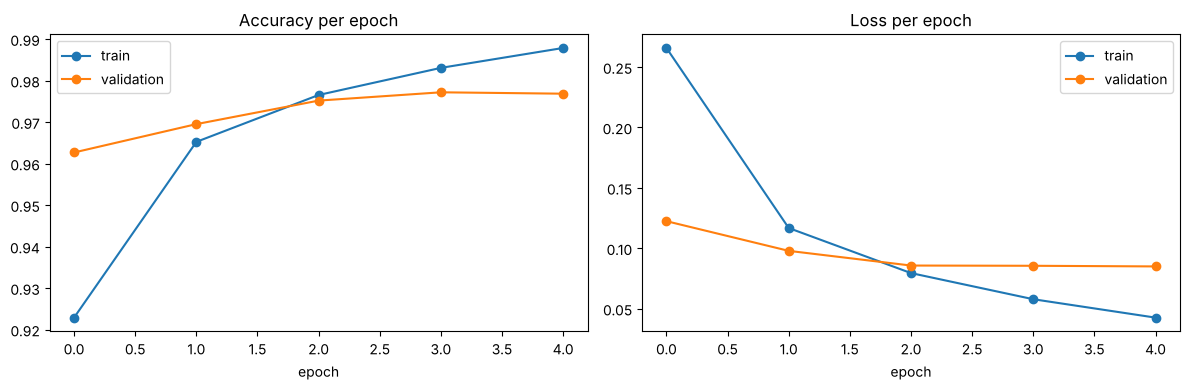

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], marker='o', label='train')
axes[0].plot(history.history['val_accuracy'], marker='o', label='validation')
axes[0].set_title('Accuracy per epoch')
axes[0].set_xlabel('epoch')
axes[0].legend()
axes[1].plot(history.history['loss'], marker='o', label='train')
axes[1].plot(history.history['val_loss'], marker='o', label='validation')
axes[1].set_title('Loss per epoch')
axes[1].set_xlabel('epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

**Comment:** with a single hidden layer of 128 neurons and only 5 epochs, the network reaches about **97–98% accuracy** on the 10,000 test images it has never seen. The training and validation curves stay close, so the model is not overfitting much yet. The 784 → 128 → 10 network has about 100,000 parameters (784×128 + 128 + 128×10 + 10 = 101,770).

## 🌟 Exercise 4: Forward Propagation Calculation

Predict a house price with x₁ = 2000 sq ft, x₂ = 3 bedrooms, w₁ = 0.5, w₂ = 0.7, b = 50,000 and a ReLU activation.

In [9]:
x1, x2 = 2000.0, 3.0
w1, w2 = 0.5, 0.7
b = 50000.0

# z = x1*w1 + x2*w2 + b
z = x1*w1 + x2*w2 + b

# ReLU: max(0, z)
y = max(0.0, z)

print({"z": z, "prediction": y})
print(f"z = 2000×0.5 + 3×0.7 + 50,000 = 1,000 + 2.1 + 50,000 = {z:,.1f}")
print(f"ReLU(z) = max(0, {z:,.1f}) = {y:,.1f}  ->  predicted price ≈ ${y:,.2f}")

{'z': 51002.1, 'prediction': 51002.1}
z = 2000×0.5 + 3×0.7 + 50,000 = 1,000 + 2.1 + 50,000 = 51,002.1
ReLU(z) = max(0, 51,002.1) = 51,002.1  ->  predicted price ≈ $51,002.10


**Interpretation:**

1. Before activation: **z = 2000 × 0.5 + 3 × 0.7 + 50,000 = 51,002.1**.
2. ReLU keeps positive values unchanged: **ReLU(51,002.1) = 51,002.1**.
3. The predicted house price is about **$51,002**.

The **bias** (50,000) is the baseline price predicted before looking at the house. It accounts for 98% of the prediction here. The square footage adds 1,000 and the bedrooms only 2.1. The **input scaling** explains these very unequal contributions: x₁ is in the thousands while x₂ is a small number, so with comparable weights the square footage dominates and the number of bedrooms is almost ignored. In a real network we would **standardise the inputs** so that each feature has a comparable scale, and the weights would be learned from data. ReLU has no effect here because z is positive; it would only matter if z were negative, in which case the prediction would be clipped to 0 (a price cannot be negative).

## 🌟 Exercise 5 (optional): Implementing Forward and Backward Propagation in Python

Predict an exam score from study hours (4) and previous test score (80), with a true score of 85.

In [10]:
import numpy as np

# Initialize input data (features)
x = np.array([4, 80])  # 4 hours studied, previous test score: 80

# Initialize weights and bias
w = np.array([0.6, 0.3])  # Initial weights
b = 10  # Initial bias

# Forward Propagation
def forward_propagation(x, w, b):
    z = np.dot(x, w) + b  # Weighted sum
    return z  # Linear activation (No ReLU here, it's a regression task)

# Compute prediction
y_pred = forward_propagation(x, w, b)
y_true = 85  # Actual exam score

# Compute Loss (Mean Squared Error)
loss = 0.5 * (y_true - y_pred) ** 2

# Compute Gradients
grad_w = -(y_true - y_pred) * x  # Partial derivatives with respect to weights
grad_b = -(y_true - y_pred)  # Partial derivative with respect to bias

# Update Weights and Bias
learning_rate = 0.01
w_new = w - learning_rate * grad_w
b_new = b - learning_rate * grad_b

# Print Results
print("Initial Prediction:", y_pred)
print("Loss:", loss)
print("Updated Weights:", w_new)
print("Updated Bias:", b_new)

Initial Prediction: 36.4
Loss: 1180.98
Updated Weights: [ 2.544 39.18 ]
Updated Bias: 10.486


In [11]:
# What happens after the update? Prediction with the new parameters
y_pred_new = forward_propagation(x, w_new, b_new)
print("Prediction after 1 update:", round(y_pred_new, 2))
print("Loss after 1 update:", round(0.5 * (y_true - y_pred_new) ** 2, 2))

Prediction after 1 update: 3155.06
Loss after 1 update: 4712640.34


lr = 0.01 (initial)                 final prediction =   -4.976e+37 | final loss = 3.102e+71
lr = 0.0001                         final prediction =           85 | final loss = 1.36e-14
lr = 0.00001                        final prediction =         72.1 | final loss = 95
lr = 0.0001, w0 = [0, 0], b0 = 0    final prediction =           85 | final loss = 4.161e-14


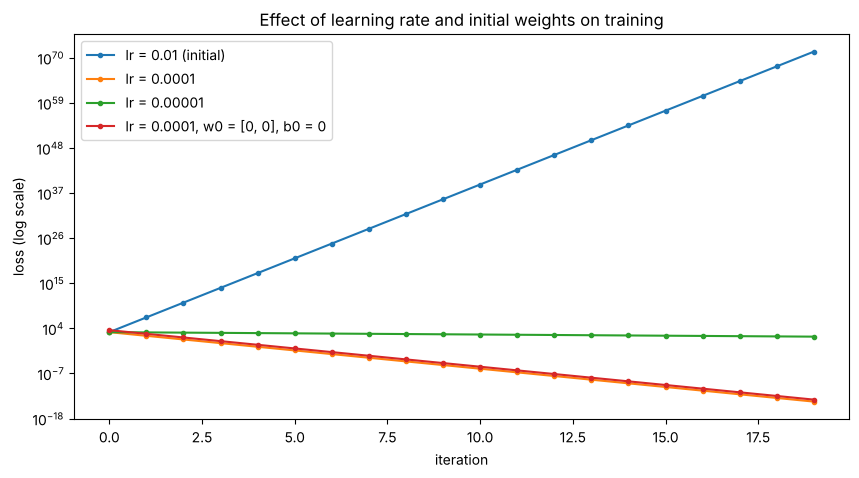

In [12]:
def train(w0, b0, learning_rate, steps=20):
    """Repeat forward + backward propagation and return the loss at each step."""
    w, b = np.array(w0, dtype=float), float(b0)
    losses = []
    for _ in range(steps):
        y_pred = forward_propagation(x, w, b)
        losses.append(0.5 * (y_true - y_pred) ** 2)
        error = y_true - y_pred
        w = w + learning_rate * error * x
        b = b + learning_rate * error
    return w, b, losses

experiments = {
    'lr = 0.01 (initial)': ([0.6, 0.3], 10, 0.01),
    'lr = 0.0001': ([0.6, 0.3], 10, 0.0001),
    'lr = 0.00001': ([0.6, 0.3], 10, 0.00001),
    'lr = 0.0001, w0 = [0, 0], b0 = 0': ([0.0, 0.0], 0, 0.0001),
}

plt.figure(figsize=(10, 5))
for label, (w0, b0, lr) in experiments.items():
    w_f, b_f, losses = train(w0, b0, lr)
    final_pred = forward_propagation(x, w_f, b_f)
    print(f"{label:<35} final prediction = {final_pred:12.4g} | final loss = {losses[-1]:.4g}")
    plt.plot(losses, marker='o', markersize=3, label=label)
plt.yscale('log')
plt.xlabel('iteration')
plt.ylabel('loss (log scale)')
plt.title('Effect of learning rate and initial weights on training')
plt.legend()
plt.show()

**Observations:**

- With the initial values, the first prediction is **36.4** (0.6×4 + 0.3×80 + 10) for a true score of 85, so the loss is 0.5 × 48.6² ≈ **1181**. The gradients are negative (the prediction is too low), so the update **increases** the weights and the bias: w becomes [2.54, 39.18] and b becomes 10.49.

**Why gradient descent reduces the error:** the gradient of the loss points in the direction in which the loss increases the fastest. Moving the parameters a small step in the *opposite* direction (w ← w − lr × gradient) therefore lowers the loss. Each weight is corrected in proportion to its input and to the size of the error: the weight of "previous score" (input 80) moves 20 times more than the weight of "hours studied" (input 4). When the error reaches 0, the gradient becomes 0 and the parameters stop changing.

**Effect of the learning rate and the initial weights:**
- **lr = 0.01 is too large here**: the step overshoots the minimum (the prediction jumps from 36 to about 3,155), and the loss explodes at each iteration. This is because the inputs are not scaled: x₂ = 80 makes the gradient very large. For this single example, gradient descent only converges if lr < 2 / (x₁² + x₂² + 1) ≈ 0.0003.
- **lr = 0.0001** converges quickly: the prediction reaches 85 and the loss falls to almost 0 within a few iterations.
- **lr = 0.00001** is stable but slow: the loss decreases, but after 20 iterations the prediction has only reached about 72 instead of 85.
- **Changing the initial weights** (starting from 0) changes the starting loss, but with a good learning rate the model still converges to a correct prediction. The initial values matter less than the choice of the learning rate.

In practice, we **scale the inputs** (e.g. standardisation) so that a single learning rate works well for every weight.

## 🌟 Exercise 6 (optional): Visualizing Predictions on MNIST

We reuse the model trained in Exercise 3 (same data loading, normalisation, one-hot encoding, architecture and compilation), then predict the test images and display some of them with their predicted label.

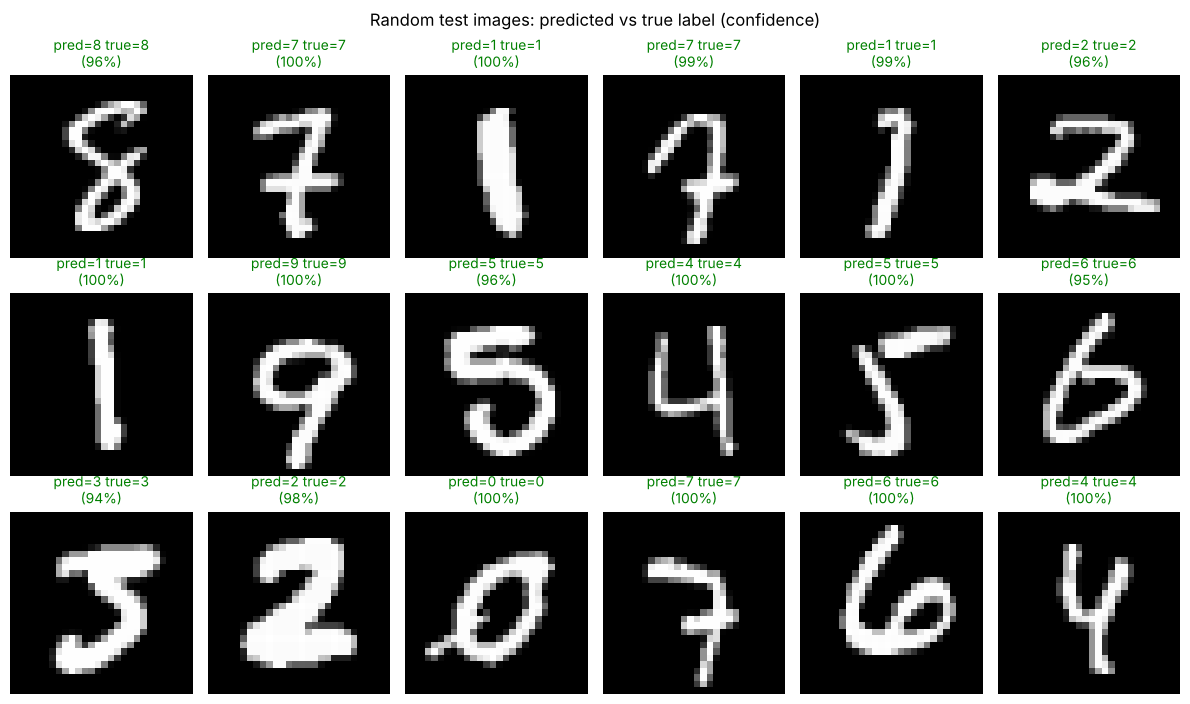

In [13]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Select N samples from x_test with np.random.choice
N = 18
idx = np.random.choice(len(x_test), size=N, replace=False)
x_vis = x_test[idx]
y_true = y_test[idx]

# Get predictions (softmax probabilities -> most likely digit)
y_prob = model.predict(x_vis, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# Plotting
cols = 6
rows = int(np.ceil(len(idx)/cols))
plt.figure(figsize=(12, 2.4*rows))
for i, k in enumerate(idx, 1):
    plt.subplot(rows, cols, i)
    plt.imshow(x_test[k], cmap="gray")
    color = 'green' if y_pred[i-1] == y_true[i-1] else 'red'
    plt.title(f"pred={y_pred[i-1]} true={y_true[i-1]}\n({y_prob[i-1].max():.0%})", color=color, fontsize=10)
    plt.axis("off")
plt.suptitle('Random test images: predicted vs true label (confidence)')
plt.tight_layout()
plt.show()

272 errors out of 10000 test images (2.72%)


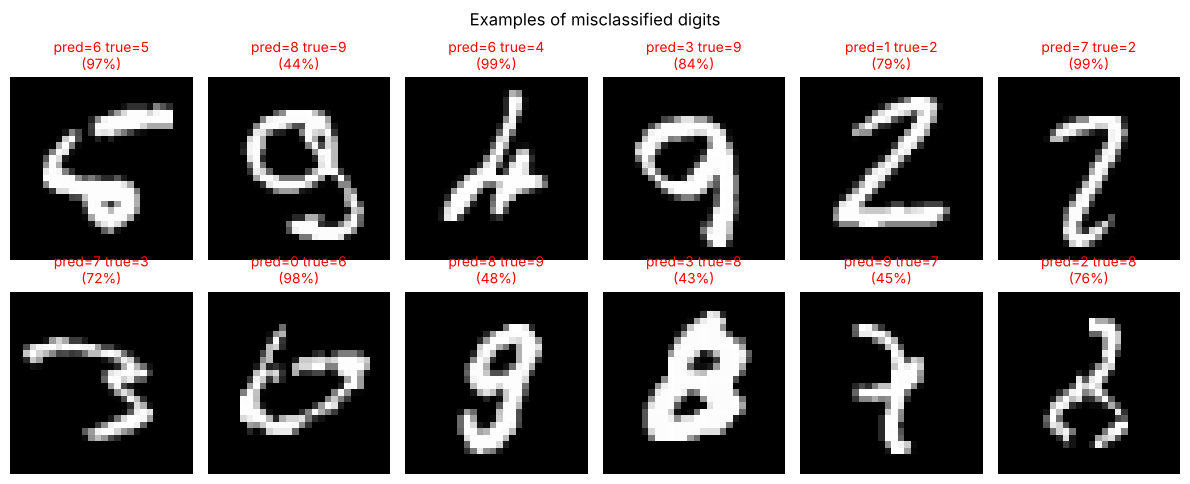

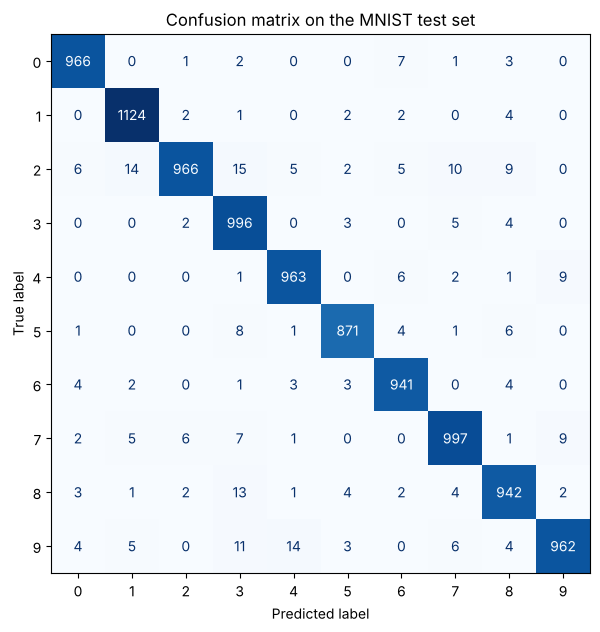

In [14]:
# Look at mistakes: which digits does the model confuse?
all_prob = model.predict(x_test, verbose=0)
all_pred = np.argmax(all_prob, axis=1)
errors = np.where(all_pred != y_test)[0]
print(f"{len(errors)} errors out of {len(y_test)} test images ({len(errors)/len(y_test):.2%})")

show = errors[:12]
plt.figure(figsize=(12, 5))
for i, k in enumerate(show, 1):
    plt.subplot(2, 6, i)
    plt.imshow(x_test[k], cmap="gray")
    plt.title(f"pred={all_pred[k]} true={y_test[k]}\n({all_prob[k].max():.0%})", color='red', fontsize=10)
    plt.axis("off")
plt.suptitle('Examples of misclassified digits')
plt.tight_layout()
plt.show()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay(confusion_matrix(y_test, all_pred)).plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Confusion matrix on the MNIST test set')
plt.show()

**Interpretation:** almost all random test images are classified correctly, usually with a confidence close to 100%. The softmax output gives a probability for each digit, and the predicted label is the most likely one. The errors are mostly on badly written or ambiguous digits (e.g. a 4 that looks like a 9, a 7 like a 2, a 5 like a 3), often with a lower confidence. The confusion matrix confirms that the mistakes concentrate on pairs of similar shapes. A convolutional neural network (CNN), which takes the 2D structure of the image into account, would reduce these errors further.